*The primary objectives of this notebook are to:*

Load and inspect the dataset structure.
Examine data types, dimensions, and statistical summaries.
Detect missing values and duplicate records.
Study the distribution of numerical and categorical variables.
Identify outliers that may influence optimization performance.
Analyze correlations among wireless communication parameters.
Investigate how key network metrics such as throughput, latency, energy consumption, SINR, transmit power, bandwidth allocation, and network load interact with each other.
Identify the most influential features affecting network performance.
Validate that the dataset is suitable for formulating a multi-objective optimization problem.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("research_grade_6g_synthetic_dataset_10000.csv")

df.head()

,User_ID,Base_Station_ID,Channel_ID,Distance_m,Carrier_Freq_GHz,Path_Loss_dB,Beamforming_Gain_dB,Tx_Power_W,Rx_Power_dBm,Interference_dBm,...,Network_Load,Packet_Size_MB,Throughput_Mbps,Latency_ms,Energy_J,Cost,User_Speed_kmph,Packet_Loss_%,QoS_Class,Priority
0,1,3,4,436.10,3.5,95.09,8.90,0.282,-31.70,-98.83,...,0.291,5.04,109.59,2.76,0.104,0.393,80.5,0.0,eMBB,Medium
1,2,1,8,258.99,28.0,103.36,9.92,0.452,-36.90,-87.39,...,0.868,6.19,83.71,5.41,0.267,0.481,28.6,0.0,mMTC,Low
2,3,5,1,437.07,2.6,95.31,16.12,0.794,-20.19,-86.62,...,0.881,7.57,110.20,5.34,0.436,0.656,104.5,0.0,mMTC,Low
3,4,4,7,342.33,2.6,81.19,18.67,1.596,-0.49,-81.40,...,0.686,0.89,268.71,3.76,0.042,1.299,91.3,0.0,eMBB,High
4,5,1,5,87.67,3.5,63.59,17.76,0.542,11.51,-88.58,...,0.523,6.89,664.13,3.33,0.045,1.272,82.1,0.0,eMBB,Low


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 24


In [4]:
df.columns

Index(['User_ID', 'Base_Station_ID', 'Channel_ID', 'Distance_m',
       'Carrier_Freq_GHz', 'Path_Loss_dB', 'Beamforming_Gain_dB', 'Tx_Power_W',
       'Rx_Power_dBm', 'Interference_dBm', 'SINR_dB', 'Required_BW_MHz',
       'Allocated_BW_MHz', 'Resource_Blocks', 'Network_Load', 'Packet_Size_MB',
       'Throughput_Mbps', 'Latency_ms', 'Energy_J', 'Cost', 'User_Speed_kmph',
       'Packet_Loss_%', 'QoS_Class', 'Priority'],
      dtype='object')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,10000.0,5000.500000,2886.895680,1.000,2500.75000,5000.5000,7500.250,10000.000
Base_Station_ID,10000.0,2.994900,1.411337,1.000,2.00000,3.0000,4.000,5.000
Channel_ID,10000.0,4.513400,2.311137,1.000,2.00000,5.0000,7.000,8.000
Distance_m,10000.0,261.057284,137.242954,20.010,142.93750,261.4000,378.245,500.000
Carrier_Freq_GHz,10000.0,7.135280,8.795669,0.700,2.60000,3.5000,6.000,28.000
Path_Loss_dB,10000.0,84.767957,13.335382,32.040,76.53000,85.9300,93.060,125.490
Beamforming_Gain_dB,10000.0,12.450051,4.334082,5.000,8.65750,12.4400,16.210,20.000
Tx_Power_W,10000.0,1.054625,0.549435,0.101,0.57975,1.0570,1.528,2.000
Rx_Power_dBm,10000.0,-12.943849,14.362958,-57.960,-22.42000,-13.6100,-3.890,47.130
Interference_dBm,10000.0,-95.004885,8.677882,-110.000,-102.56250,-94.8600,-87.540,-80.000


In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [7]:
df.duplicated().sum()

np.int64(0)

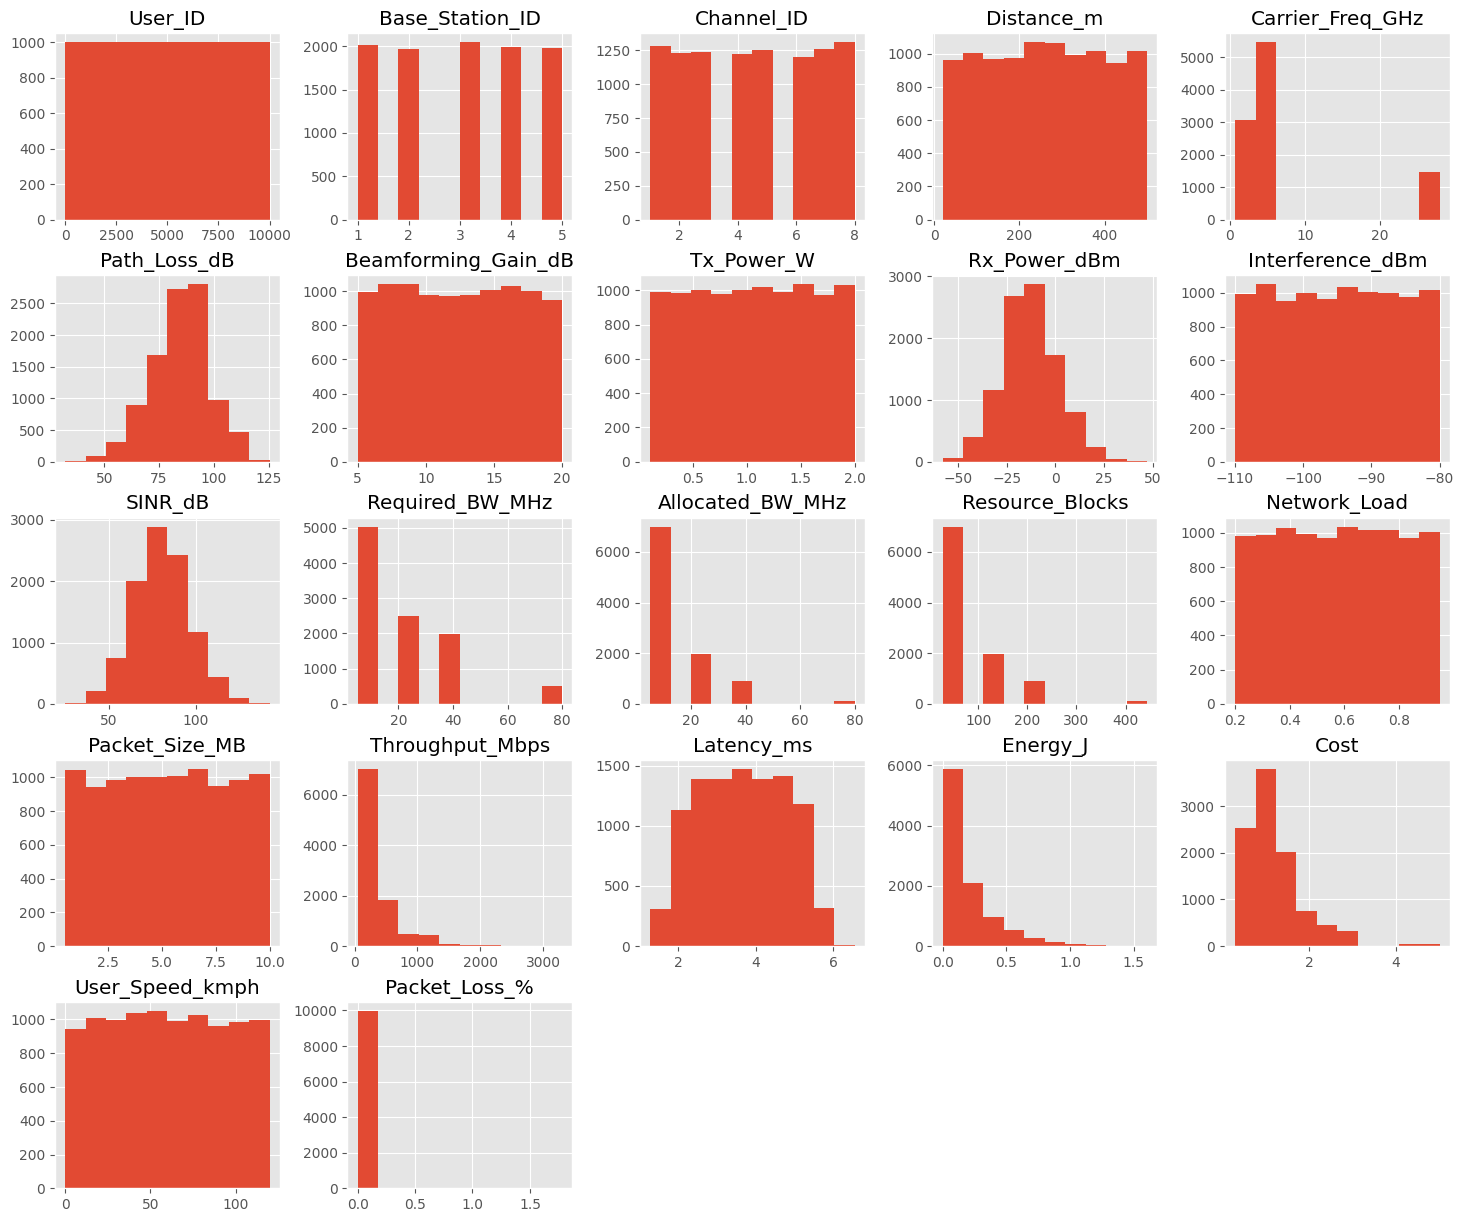

In [8]:
df.hist(figsize=(18,15))

plt.show()

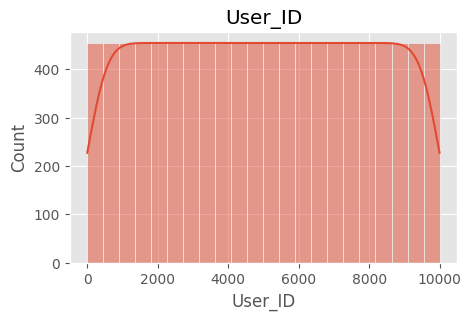

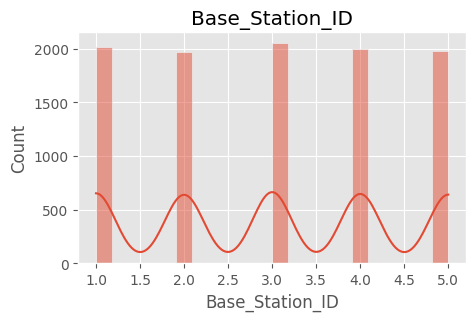

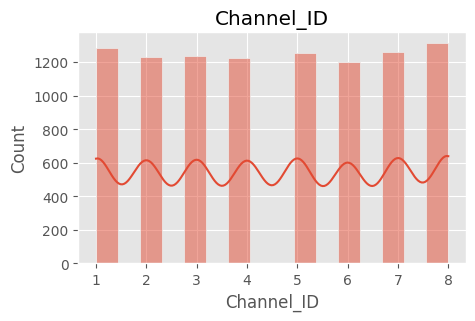

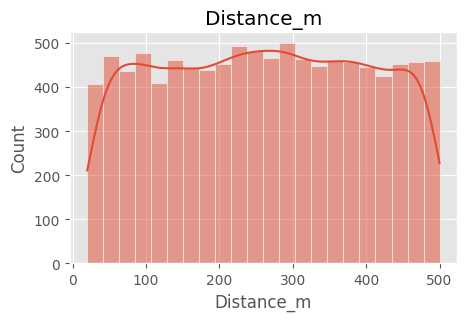

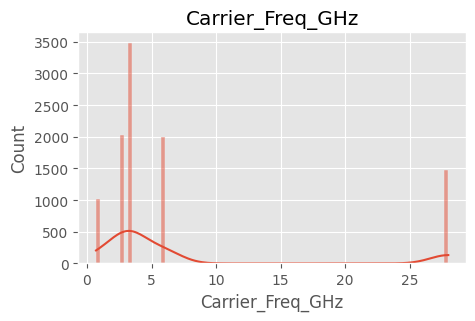

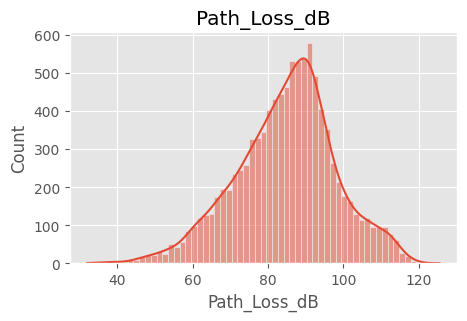

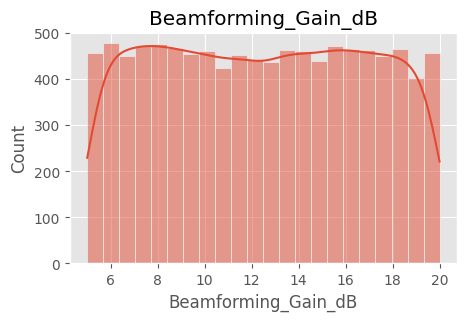

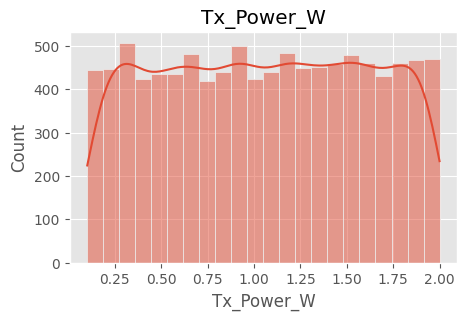

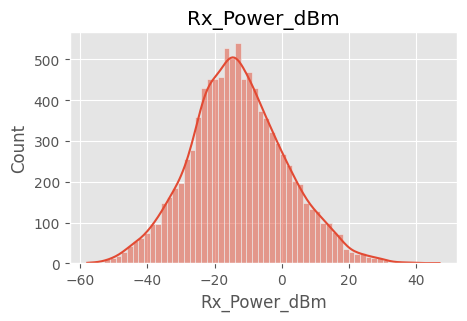

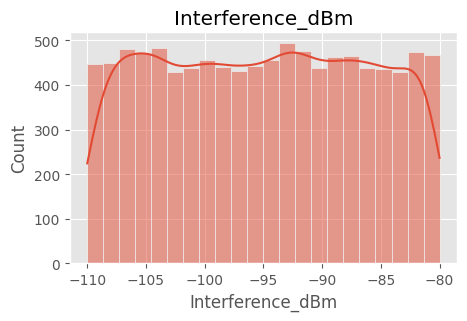

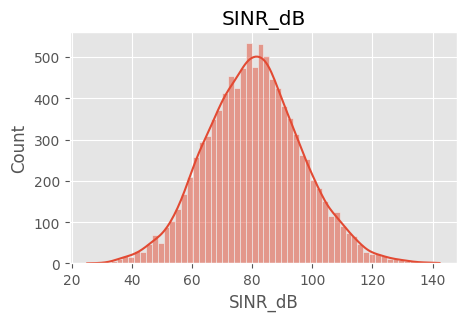

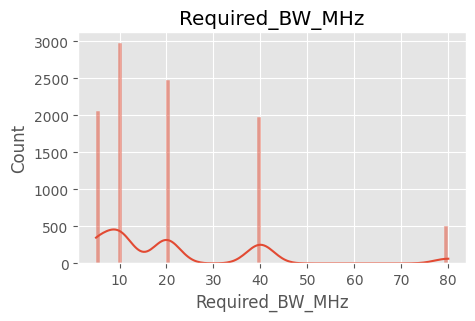

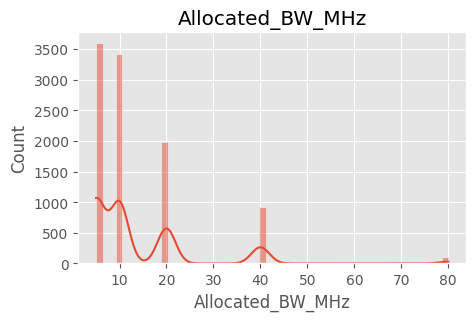

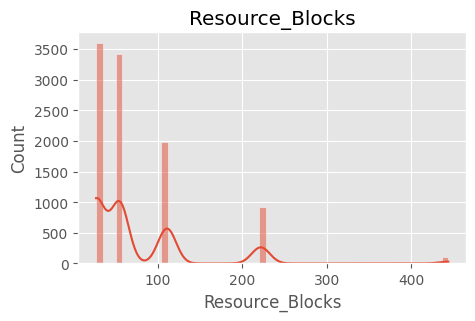

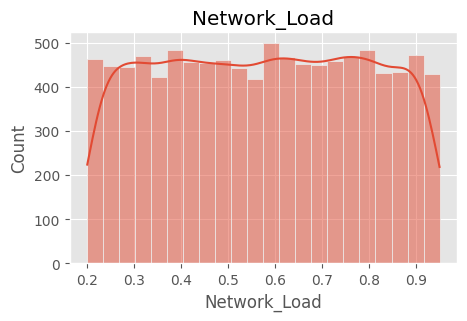

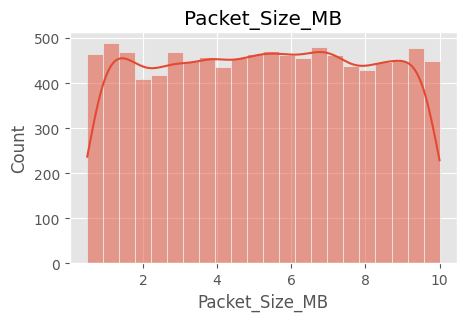

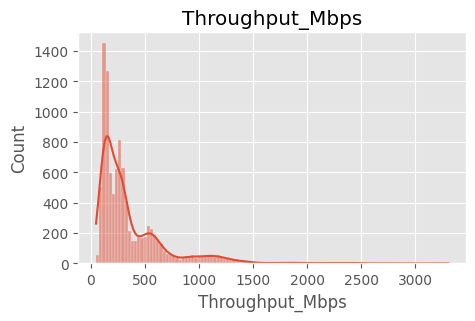

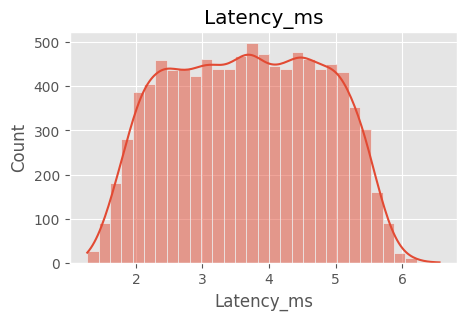

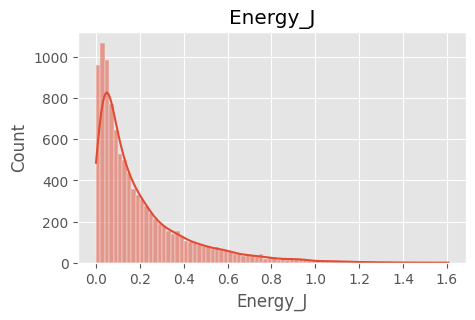

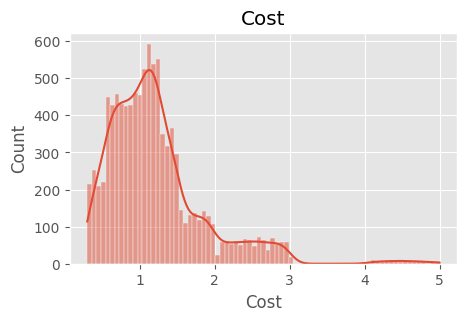

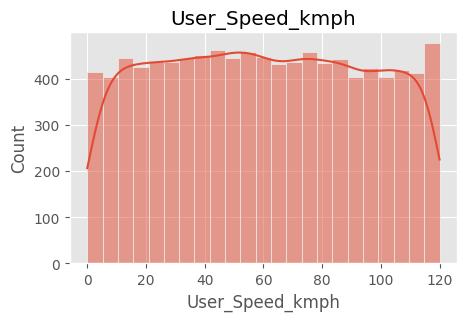

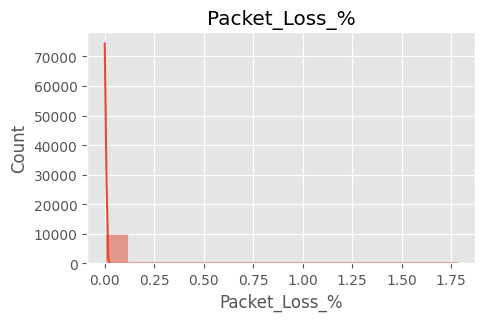

In [9]:
numerical = df.select_dtypes(include=np.number).columns

for col in numerical:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

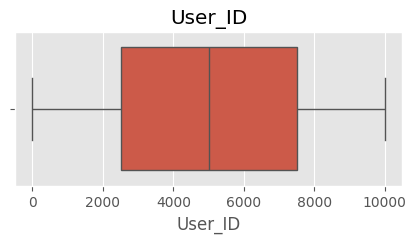

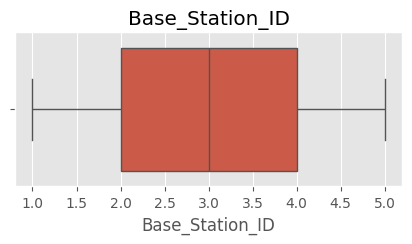

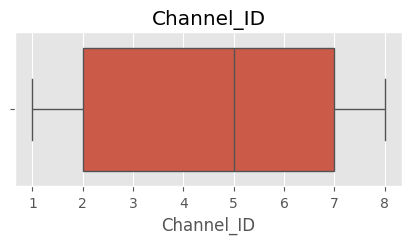

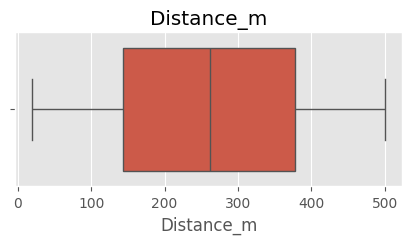

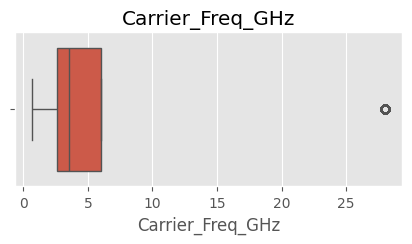

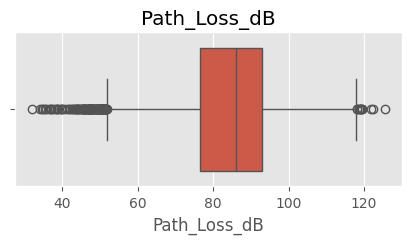

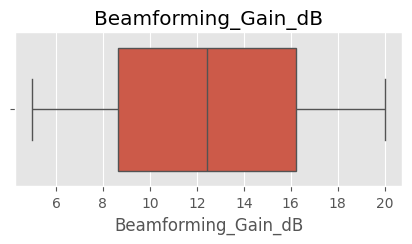

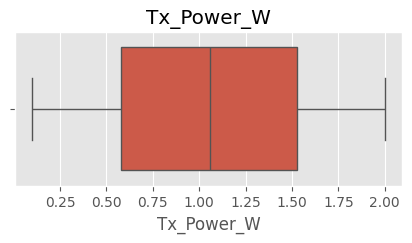

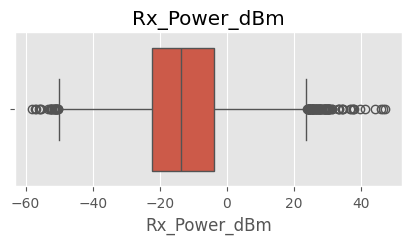

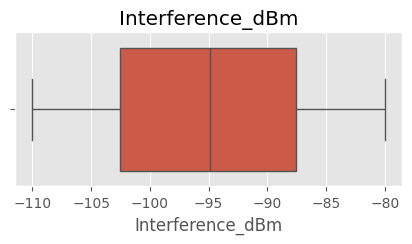

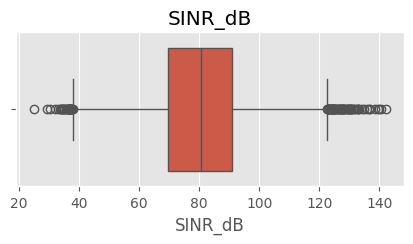

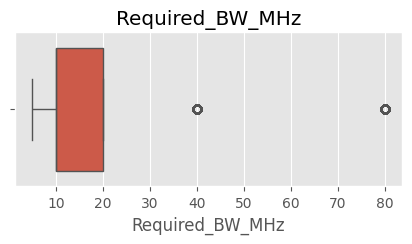

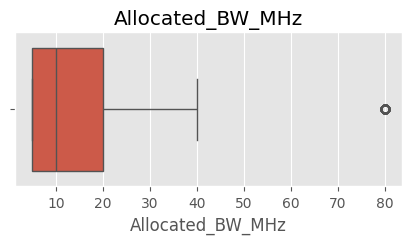

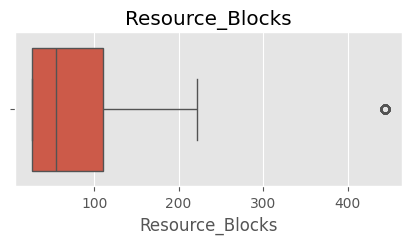

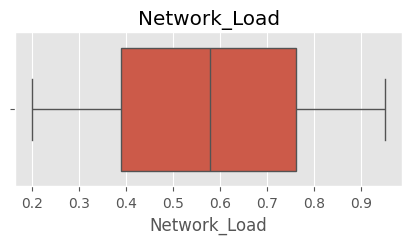

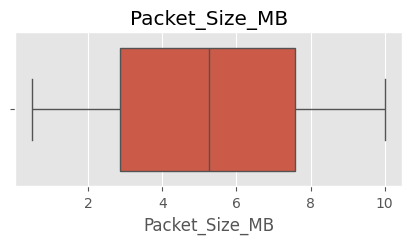

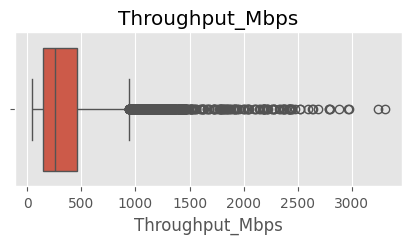

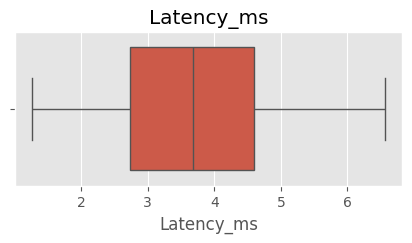

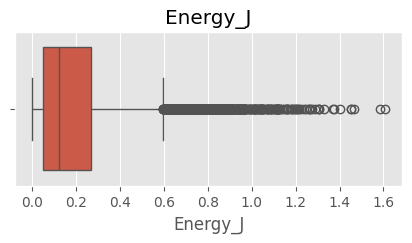

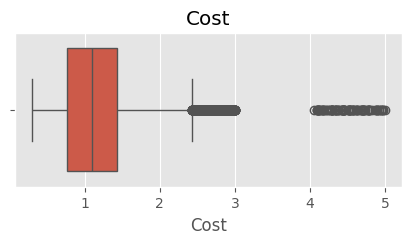

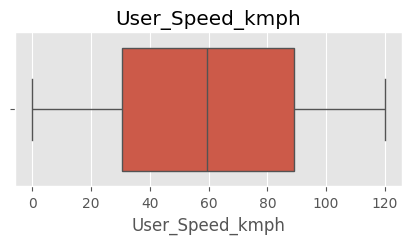

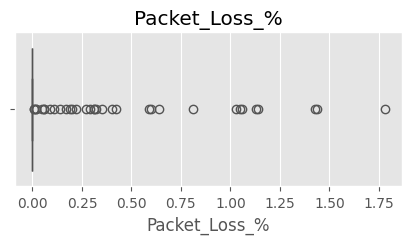

In [10]:
for col in numerical:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [11]:
for col in numerical:

    print(col,

          skew(df[col]))

User_ID 0.0
Base_Station_ID 0.000915312333108516
Channel_ID -0.004411770767366575
Distance_m -0.005791599998119596
Carrier_Freq_GHz 1.8722152086682828
Path_Loss_dB -0.2900052881177423
Beamforming_Gain_dB 0.010834553012387045
Tx_Power_W -0.009106689324828506
Rx_Power_dBm 0.21178893145748798
Interference_dBm 0.0022508157515687454
SINR_dB 0.12530831514313734
Required_BW_MHz 1.7147986831901791
Allocated_BW_MHz 2.4729238357278205
Resource_Blocks 2.4590508893109804
Network_Load -0.0027247949701516786
Packet_Size_MB -0.0077700436812741715
Throughput_Mbps 2.617271029690287
Latency_ms -0.007643104370596571
Energy_J 1.9339282546563792
Cost 1.8464933095273692
User_Speed_kmph 0.017668386468000303
Packet_Loss_% 30.287808364544208


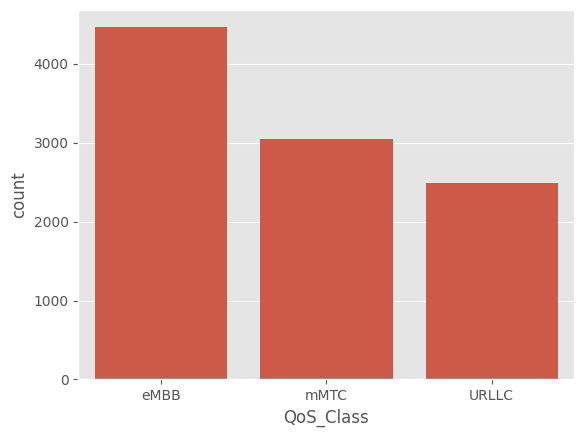

In [12]:
sns.countplot(data=df,

              x="QoS_Class")

plt.show()

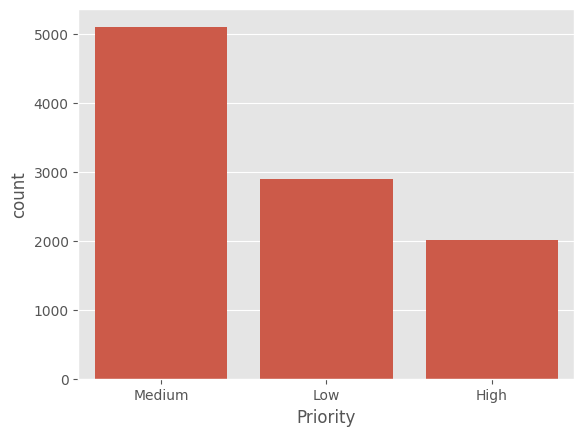

In [13]:
sns.countplot(data=df,

              x="Priority")

plt.show()

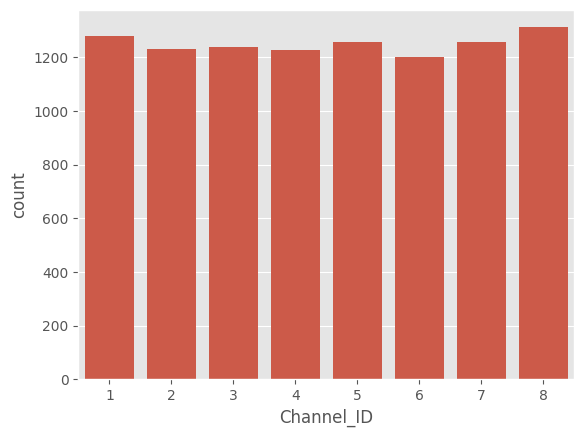

In [14]:
sns.countplot(data=df,

              x="Channel_ID")

plt.show()

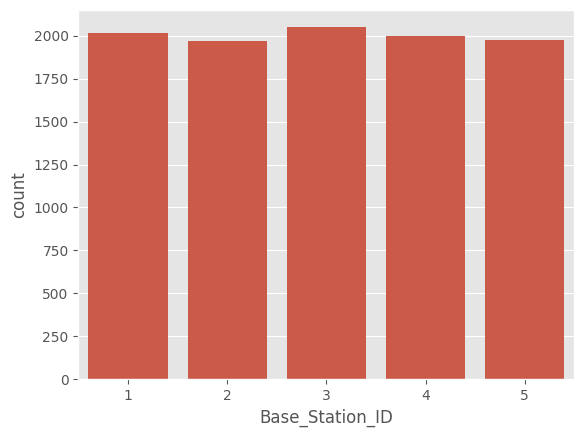

In [15]:
sns.countplot(data=df,

              x="Base_Station_ID")

plt.show()

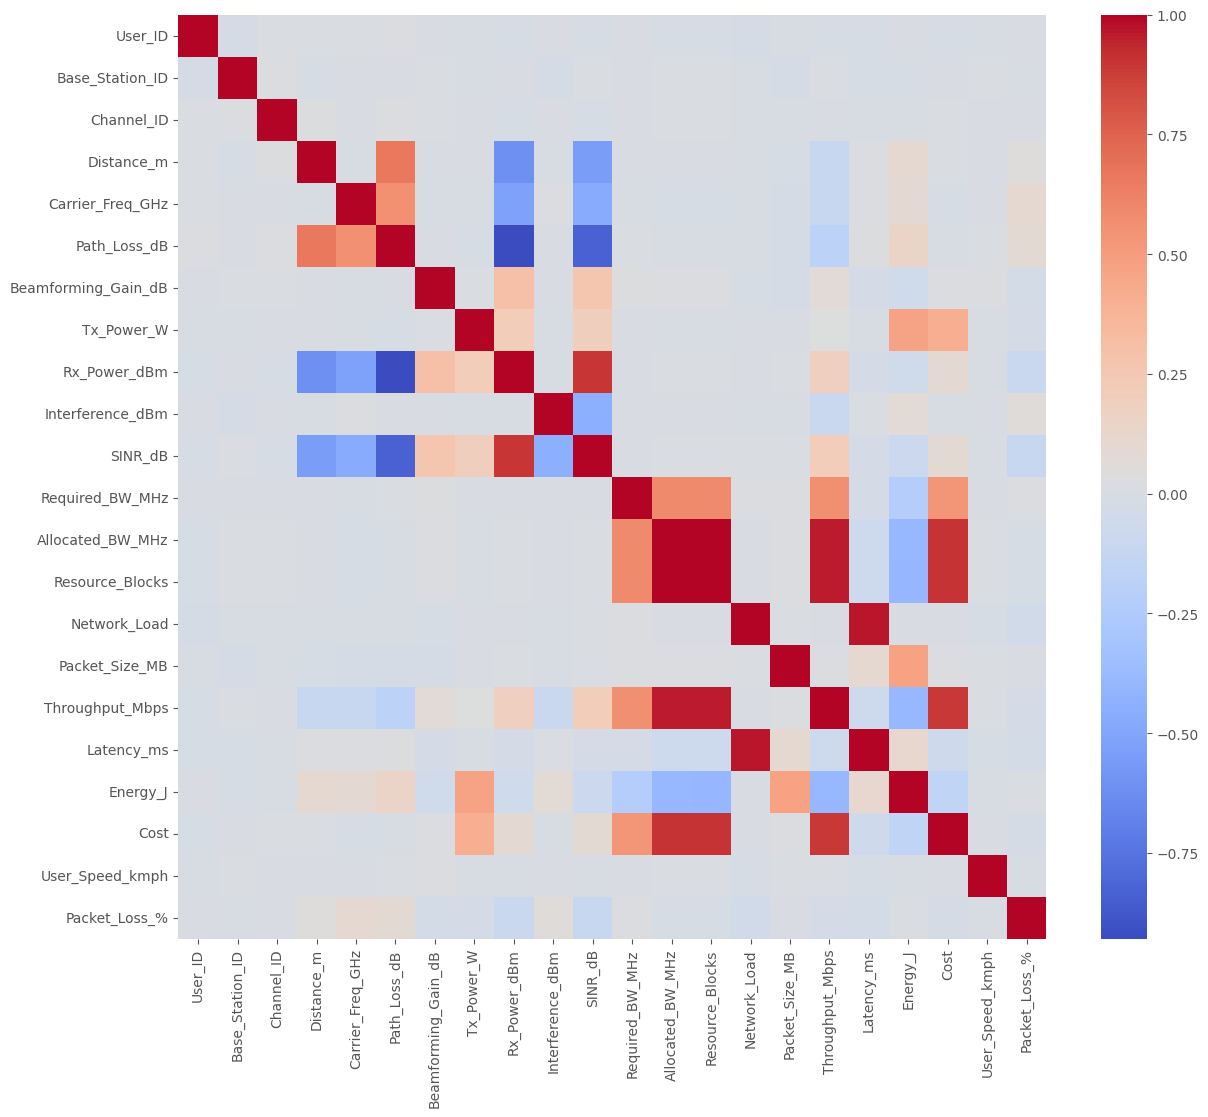

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,12))

sns.heatmap(corr,

            cmap="coolwarm",

            annot=False)

plt.show()

In [17]:
corr["Throughput_Mbps"].sort_values(ascending=False)

Throughput_Mbps        1.000000
Resource_Blocks        0.960816
Allocated_BW_MHz       0.960814
Cost                   0.889283
Required_BW_MHz        0.565949
SINR_dB                0.215466
Rx_Power_dBm           0.193007
Beamforming_Gain_dB    0.068302
Tx_Power_W             0.032767
Packet_Size_MB         0.019501
User_Speed_kmph        0.008264
Base_Station_ID        0.006105
Network_Load           0.003678
Channel_ID             0.003187
User_ID               -0.011539
Packet_Loss_%         -0.029494
Latency_ms            -0.073173
Interference_dBm      -0.093254
Distance_m            -0.109685
Carrier_Freq_GHz      -0.110020
Path_Loss_dB          -0.177467
Energy_J              -0.389591
Name: Throughput_Mbps, dtype: float64

In [18]:
corr["Energy_J"].sort_values()

Resource_Blocks       -0.393971
Allocated_BW_MHz      -0.393224
Throughput_Mbps       -0.389591
Required_BW_MHz       -0.221763
Cost                  -0.160031
SINR_dB               -0.086791
Beamforming_Gain_dB   -0.062166
Rx_Power_dBm          -0.057537
Base_Station_ID       -0.015844
Channel_ID            -0.004765
User_Speed_kmph       -0.004334
Network_Load          -0.000048
User_ID                0.003870
Packet_Loss_%          0.011649
Interference_dBm       0.079243
Carrier_Freq_GHz       0.088461
Distance_m             0.099410
Latency_ms             0.113318
Path_Loss_dB           0.143515
Tx_Power_W             0.465779
Packet_Size_MB         0.479945
Energy_J               1.000000
Name: Energy_J, dtype: float64

In [19]:
corr["Latency_ms"].sort_values()

Throughput_Mbps       -0.073173
Resource_Blocks       -0.072230
Allocated_BW_MHz      -0.072070
Cost                  -0.066617
Packet_Loss_%         -0.036962
SINR_dB               -0.031720
Rx_Power_dBm          -0.031075
Required_BW_MHz       -0.027082
Beamforming_Gain_dB   -0.025137
Base_Station_ID       -0.014755
User_ID               -0.014564
User_Speed_kmph       -0.012811
Channel_ID            -0.005809
Tx_Power_W            -0.003581
Interference_dBm       0.009093
Distance_m             0.014268
Carrier_Freq_GHz       0.015812
Path_Loss_dB           0.024327
Packet_Size_MB         0.097787
Energy_J               0.113318
Network_Load           0.966791
Latency_ms             1.000000
Name: Latency_ms, dtype: float64

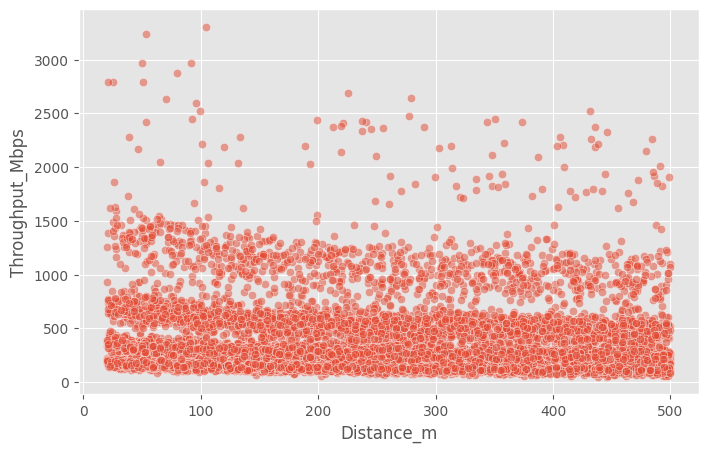

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,

                x="Distance_m",

                y="Throughput_Mbps",

                alpha=0.5)

plt.show()

<Axes: xlabel='Distance_m', ylabel='Path_Loss_dB'>

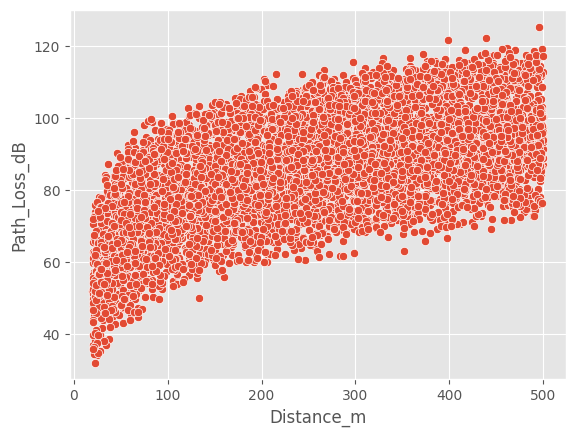

In [21]:
sns.scatterplot(data=df,

                x="Distance_m",

                y="Path_Loss_dB")

<Axes: xlabel='SINR_dB', ylabel='Throughput_Mbps'>

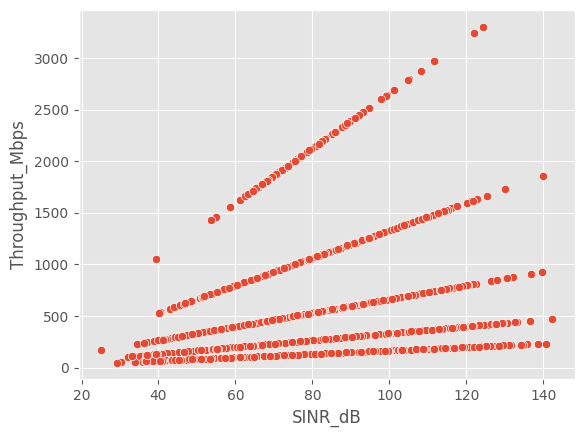

In [22]:
sns.scatterplot(data=df,

                x="SINR_dB",

                y="Throughput_Mbps")

<Axes: xlabel='Network_Load', ylabel='Latency_ms'>

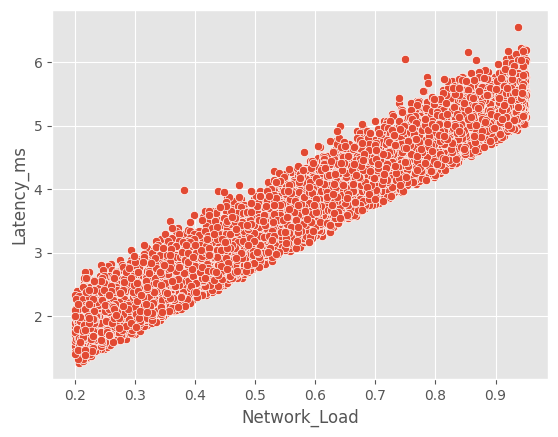

In [23]:
sns.scatterplot(data=df,

                x="Network_Load",

                y="Latency_ms")

<Axes: xlabel='Packet_Size_MB', ylabel='Latency_ms'>

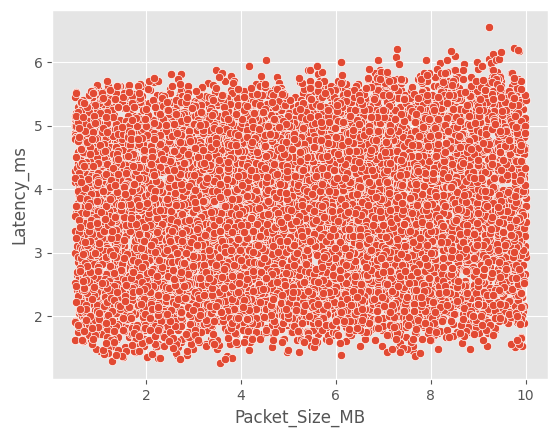

In [24]:
sns.scatterplot(data=df,

                x="Packet_Size_MB",

                y="Latency_ms")

<Axes: xlabel='Allocated_BW_MHz', ylabel='Throughput_Mbps'>

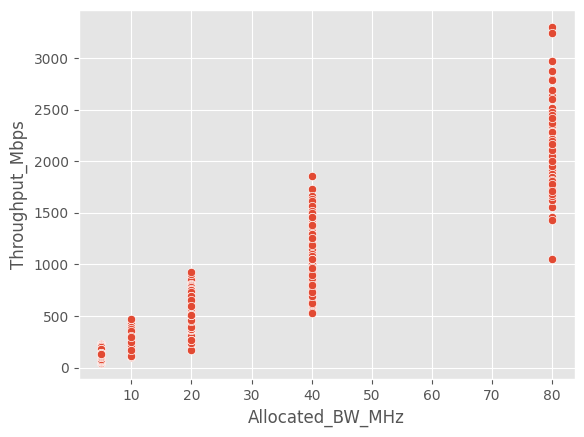

In [25]:
sns.scatterplot(data=df,

                x="Allocated_BW_MHz",

                y="Throughput_Mbps")

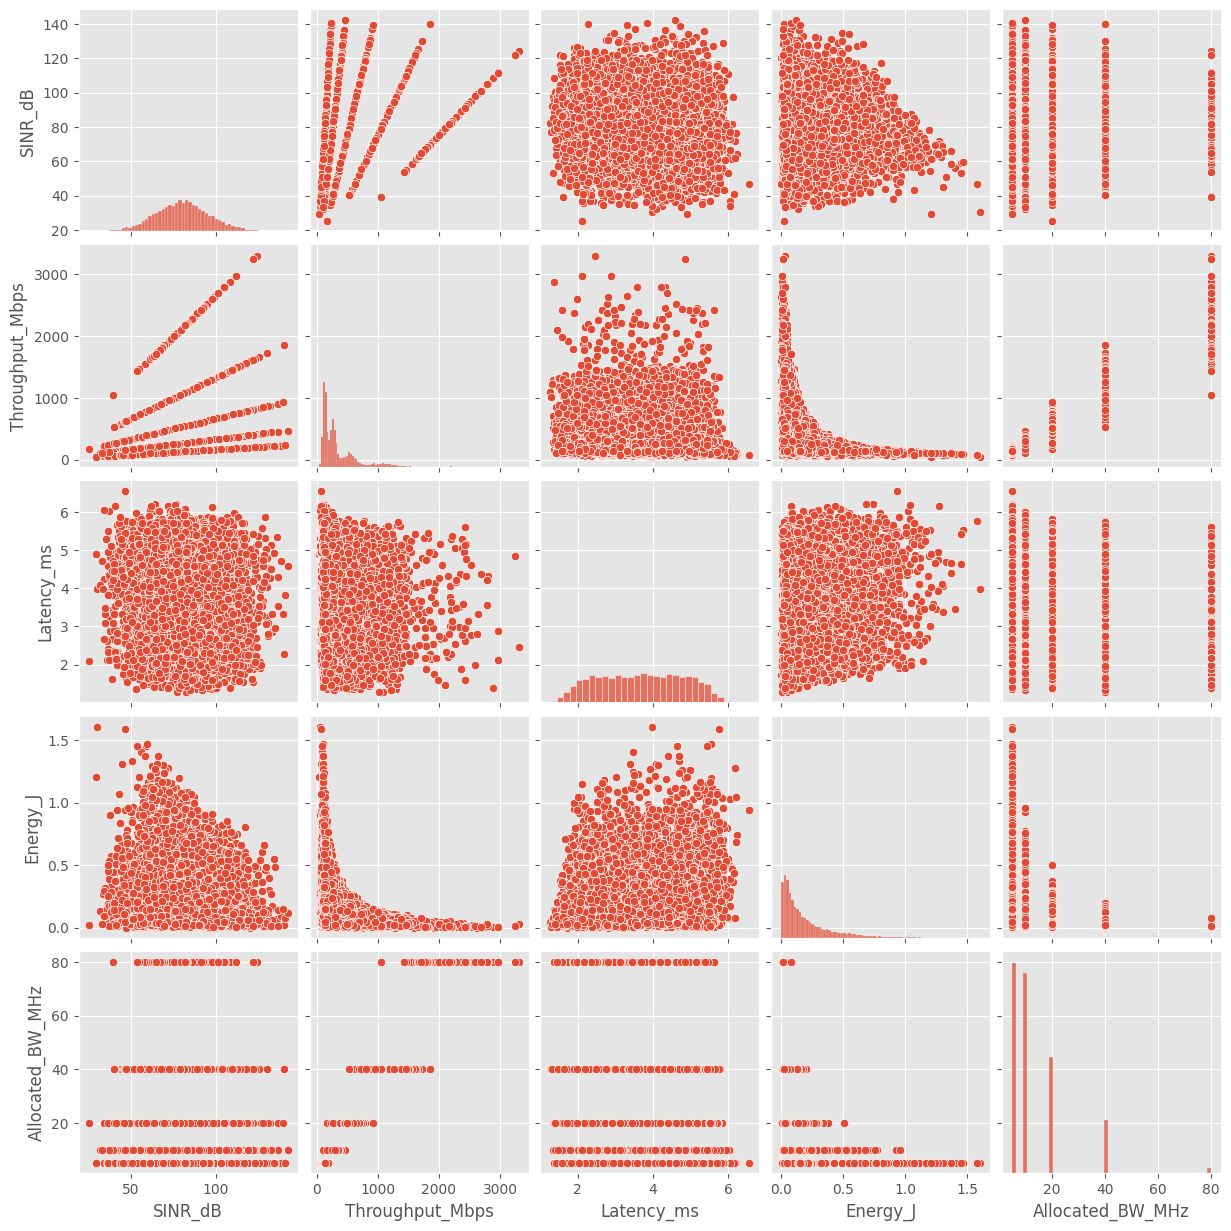

In [26]:
sns.pairplot(

df[["SINR_dB",

"Throughput_Mbps",

"Latency_ms",

"Energy_J",

"Allocated_BW_MHz"]]

)

<Axes: xlabel='QoS_Class', ylabel='Latency_ms'>

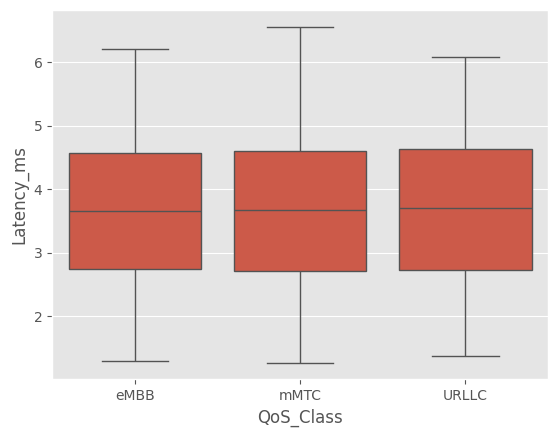

In [27]:
sns.boxplot(data=df,

            x="QoS_Class",

            y="Latency_ms")

<Axes: xlabel='Priority', ylabel='Throughput_Mbps'>

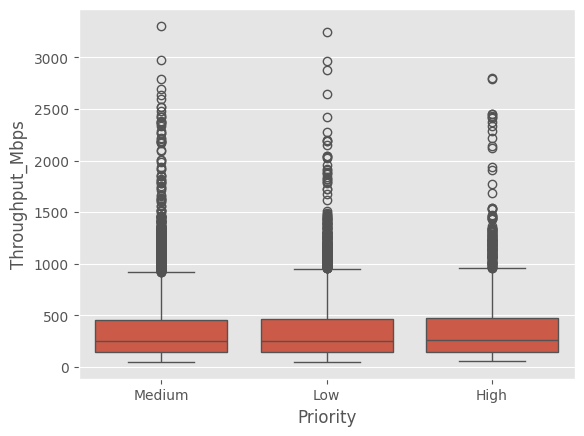

In [28]:
sns.boxplot(data=df,

            x="Priority",

            y="Throughput_Mbps")

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.drop(columns=[
    "Throughput_Mbps",
    "QoS_Class",
    "Priority"
])

X = pd.get_dummies(X)

y = df["Throughput_Mbps"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(15))

             Feature  Importance
18              Cost    0.352653
12  Allocated_BW_MHz    0.300042
13   Resource_Blocks    0.270920
10           SINR_dB    0.075301
8       Rx_Power_dBm    0.000482
5       Path_Loss_dB    0.000252
14      Network_Load    0.000051
17          Energy_J    0.000045
9   Interference_dBm    0.000043
4   Carrier_Freq_GHz    0.000035
3         Distance_m    0.000032
7         Tx_Power_W    0.000028
15    Packet_Size_MB    0.000021
0            User_ID    0.000020
19   User_Speed_kmph    0.000018


SUMMARY:

Path loss increases with user distance.
Higher SINR leads to higher throughput.
Increased network load results in higher latency.
Energy consumption grows with transmit power and transmission time.
Allocated bandwidth has a strong positive impact on throughput.
No missing values or duplicate records were found.
The dataset exhibits realistic correlations suitable for optimization.